In [1]:
!pip install --quiet timm albumentations

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

import torchvision.transforms as T
from PIL import Image

from collections import defaultdict
# from torch.amp import autocast

import timm

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

CUDA available: True
Number of GPUs: 2


In [4]:
def split_list(data, test_ratio=0.2, seed=42):
    rng = random.Random(seed)
    data = data.copy()
    rng.shuffle(data)
    split = int(len(data) * (1 - test_ratio))
    return data[:split], data[split:]
    

def confusion_matrix_np(y_true, y_pred, num_classes=2):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm
    

def classification_report_np(y_true, y_pred):
    classes = ["real", "fake"]
    for i, name in enumerate(classes):
        tp = sum((y_true == i) & (y_pred == i))
        fp = sum((y_true != i) & (y_pred == i))
        fn = sum((y_true == i) & (y_pred != i))

        precision = tp / (tp + fp + 1e-9)
        recall    = tp / (tp + fn + 1e-9)
        f1        = 2 * precision * recall / (precision + recall + 1e-9)

        print(f"{name:5s} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")


def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


def aggregate_temporal_topk(probs, k_ratio=0.2):
    """
    Temporal-aware Top-K aggregation
    probs: list of frame-level fake probabilities in order
    """
    probs = np.array(probs)

    # Smooth probabilities (temporal consistency)
    smoothed = np.convolve(probs, np.ones(3)/3, mode="same")

    k = max(1, int(len(smoothed) * k_ratio))
    topk = np.sort(smoothed)[-k:]

    return np.mean(topk)



def find_best_threshold(fpr, tpr, thresholds):
    """
    Youden's J statistic = TPR - FPR
    """
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

In [5]:
DATASET_ROOT = "/kaggle/input/faceforencispp-extracted-frames"
assert os.path.exists(DATASET_ROOT), "Dataset path not found!"

real_path = os.path.join(DATASET_ROOT, "real")
fake_path = os.path.join(DATASET_ROOT, "fake")

print("Real folders:", len(os.listdir(real_path)))
print("Fake folders:", len(os.listdir(fake_path)))

Real folders: 999
Fake folders: 5


In [6]:
real_imgs = glob(real_path + "/**/*.png", recursive=True)
fake_imgs = glob(fake_path + "/**/*.png", recursive=True)

print("Total REAL images  :", len(real_imgs))
print("Total FAKE images  :", len(fake_imgs))
print("TOTAL images       :", len(real_imgs) + len(fake_imgs))

Total REAL images  : 31949
Total FAKE images  : 159601
TOTAL images       : 191550


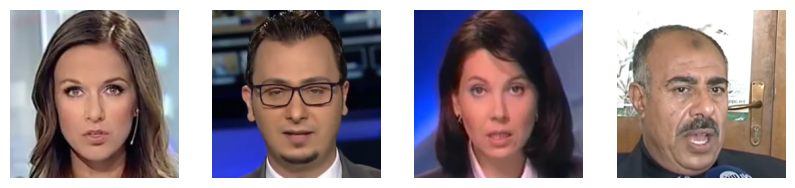

In [7]:
# Sample random real images
sample_real = np.random.choice(real_imgs, 4)

plt.figure(figsize=(10,4))
for i, img in enumerate(sample_real):
    im = cv2.imread(img)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.subplot(1,4,i+1)
    plt.imshow(im)
    plt.axis('off')
plt.show()

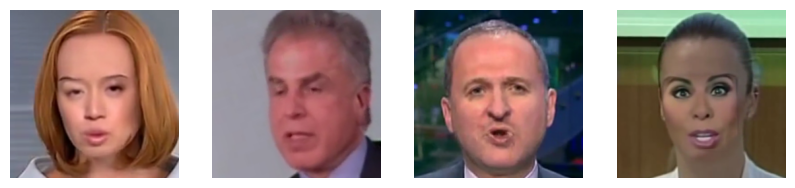

In [8]:
# Sample random fake images
sample_fake = np.random.choice(fake_imgs, 4)

plt.figure(figsize=(10,4))
for i, img in enumerate(sample_fake):
    im = cv2.imread(img)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.subplot(1,4,i+1)
    plt.imshow(im)
    plt.axis('off')
plt.show()

In [9]:
SEED = 42
TEST_RATIO = 0.2
VAL_RATIO  = 0.1

# get folder names
real_folders = sorted([os.path.join(real_path,d)
                       for d in os.listdir(real_path)
                       if os.path.isdir(os.path.join(real_path,d))])

fake_folders = []
for method in os.listdir(fake_path):
    method_path = os.path.join(fake_path,method)
    if os.path.isdir(method_path):
        fake_folders += sorted([os.path.join(method_path,d)
                                for d in os.listdir(method_path)
                                if os.path.isdir(os.path.join(method_path,d))])

print("Real video folders:", len(real_folders))
print("Fake video folders:", len(fake_folders))

# split by folder (not by frame)
train_real, test_real = split_list(real_folders, 0.2)
train_real, val_real  = split_list(train_real, 0.1)

train_fake, test_fake = split_list(fake_folders, 0.2)
train_fake, val_fake  = split_list(train_fake, 0.1)

print("Train Real:", len(train_real))
print("Val Real: ", len(val_real))
print("Test Real:", len(test_real))

print("Train Fake:", len(train_fake))
print("Val Fake: ", len(val_fake))
print("Test Fake:", len(test_fake))

Real video folders: 999
Fake video folders: 4996
Train Real: 719
Val Real:  80
Test Real: 200
Train Fake: 3596
Val Fake:  400
Test Fake: 1000


In [10]:
train_transforms = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3, 0.1),
    T.RandomRotation(10),
    T.PILToTensor(),                 # ← FIX
    T.ConvertImageDtype(torch.float32),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])


val_transforms = T.Compose([
    T.Resize((224, 224)),
    T.PILToTensor(),                 # ← FIX
    T.ConvertImageDtype(torch.float32),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])

In [11]:
class FrameFolderDataset(Dataset):
    def __init__(self, folder_list, label, transform=None, max_frames=20):
        """
        folder_list : list of video folders
        label       : 0 (real) or 1 (fake)
        transform   : torchvision transforms
        max_frames  : max frames per video
        """
        self.items = []
        self.transform = transform

        for folder in folder_list:
            frames = sorted(glob(os.path.join(folder, "*.png")))

            if len(frames) == 0:
                continue

            # limit frames per video
            if len(frames) > max_frames:
                frames = random.sample(frames, max_frames)

            for frame_path in frames:
                self.items.append((frame_path, label))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        # 🔥 RETURN PATH ALSO
        return img, label, img_path

In [12]:
BATCH_SIZE = 24   # Safe for 2× T4
MAX_FRAMES_PER_VIDEO = 20

train_ds = ConcatDataset([
    FrameFolderDataset(train_real, 0, train_transforms, MAX_FRAMES_PER_VIDEO),
    FrameFolderDataset(train_fake, 1, train_transforms, MAX_FRAMES_PER_VIDEO)
])

val_ds = ConcatDataset([
    FrameFolderDataset(val_real, 0, val_transforms, MAX_FRAMES_PER_VIDEO),
    FrameFolderDataset(val_fake, 1, val_transforms, MAX_FRAMES_PER_VIDEO)
])

test_ds = ConcatDataset([
    FrameFolderDataset(test_real, 0, val_transforms, MAX_FRAMES_PER_VIDEO),
    FrameFolderDataset(test_fake, 1, val_transforms, MAX_FRAMES_PER_VIDEO)
])


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [13]:
def get_video_id_from_path(img_path):
    """
    Extract unique video id from frame path.
    Works for:
      real/video_x/frame.png
      fake/method/video_x/frame.png
    """
    parts = img_path.split(os.sep)

    if "real" in parts:
        idx = parts.index("real")
        return "real_" + parts[idx + 1]

    if "fake" in parts:
        idx = parts.index("fake")
        return "fake_" + parts[idx + 2]

    return None


def evaluate_video_level(model, loader, threshold):
    """
    Video-level evaluation using:
    - raw logits (NOT softmax)
    - temporal smoothing
    - top-k aggregation
    """

    model.eval()

    video_logits = defaultdict(list)
    video_labels = {}

    with torch.no_grad():
        for imgs, labels, paths in loader:
            imgs = imgs.to(device)

            outputs = model(imgs)

            # 🔥 USE LOGITS (fake vs real)
            logits = outputs[:, 1] - outputs[:, 0]

            for path, logit, label in zip(paths, logits, labels):
                video_id = get_video_id_from_path(path)
                video_logits[video_id].append(logit.item())
                video_labels[video_id] = label.item()

    y_true = []
    y_pred = []

    for vid in video_logits:
        logits = np.array(video_logits[vid])

        # 🔥 Temporal smoothing
        if len(logits) >= 3:
            logits = np.convolve(logits, np.ones(3) / 3, mode="same")

        # 🔥 Top-K aggregation
        k = max(1, int(len(logits) * 0.2))
        score = np.mean(np.sort(logits)[-k:])

        pred = int(score > threshold)

        y_true.append(video_labels[vid])
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)

In [14]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block for ViT tokens
    """
    def __init__(self, dim, reduction=32):  # 🔥 was 16
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(dim // reduction, dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        x: [B, N, C]
        """
        w = x.mean(dim=1)           # [B, C]
        w = self.fc(w).unsqueeze(1) # [B, 1, C]
        return x * w

In [15]:
class ViTWithSE(nn.Module):
    def __init__(self):
        super().__init__()

        # Base ViT backbone (no classifier)
        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        embed_dim = self.vit.embed_dim

        # -------- Patch Embeddings --------
        # 16×16 (native ViT)
        self.patch_embed_16 = self.vit.patch_embed

        # 32×32 (coarser scale, NO positional embedding)
        self.patch_embed_32 = timm.layers.PatchEmbed(
            img_size=224,
            patch_size=32,
            in_chans=3,
            embed_dim=embed_dim
        )

        # -------- CLS Fusion --------
        self.cls_fusion = nn.Linear(embed_dim * 2, embed_dim)

        # -------- SE Block --------
        self.se = SEBlock(embed_dim, reduction=32)

        # -------- Classification Head --------
        self.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(embed_dim, 2)
        )

    def forward(self, x):
        # ===== 16×16 PATCH PATH (WITH POSITIONAL EMBEDDING) =====
        x16 = self.patch_embed_16(x)     # [B, N16, C]
        x16 = self.vit._pos_embed(x16)  # includes CLS + pos embed

        # ===== 32×32 PATCH PATH (NO POSITIONAL EMBEDDING) =====
        x32 = self.patch_embed_32(x)     # [B, N32, C]

        # ===== CLS TOKEN FUSION =====
        cls16 = x16[:, 0]                # [B, C]
        cls32 = x32[:, 0]                # [B, C]

        cls_fused = self.cls_fusion(
            torch.cat([cls16, cls32], dim=-1)
        )                                # [B, C]

        # Replace CLS token early
        x = torch.cat(
            [cls_fused.unsqueeze(1), x16[:, 1:]],
            dim=1
        )                                # [B, N16, C]

        # ===== SE ON PATCH TOKENS =====
        cls_tok = x[:, :1]               # keep CLS intact
        patch_tok = self.se(x[:, 1:])    # channel attention
        x = torch.cat([cls_tok, patch_tok], dim=1)

        # ===== TRANSFORMER ENCODER =====
        x = self.vit.blocks(x)
        x = self.vit.norm(x)

        # ===== CLASSIFICATION =====
        return self.head(x[:, 0])

In [16]:
# Create model
model = ViTWithSE()

# Unfreeze all parameters (correct for full fine-tuning)
for param in model.parameters():
    param.requires_grad = True

# Move to device
model = model.to(device)

# (Optional but recommended) Print model summary sanity check
print(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViTWithSE(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): 

In [17]:
num_real_frames = len(train_real) * MAX_FRAMES_PER_VIDEO
num_fake_frames = len(train_fake) * MAX_FRAMES_PER_VIDEO

w_real = num_fake_frames / (num_real_frames + num_fake_frames)
w_fake = num_real_frames / (num_real_frames + num_fake_frames)

class_weights = torch.tensor([w_real, w_fake]).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,          # 🔥 critical change
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=1
)

# from torch.cuda.amp import autocast, GradScaler
# scaler = GradScaler()

In [18]:
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for imgs, labels, _ in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ✅ CORRECT accuracy computation
        preds = outputs.argmax(dim=1)
        correct += preds.eq(labels).sum().item()

    return total_loss / len(loader), 100 * correct / len(loader.dataset)



def eval_one_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            # ✅ CORRECT accuracy computation
            preds = outputs.argmax(dim=1)
            correct += preds.eq(labels).sum().item()

    return total_loss / len(loader), 100 * correct / len(loader.dataset)

In [19]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc     = eval_one_epoch(model, val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train: loss={train_loss:.4f}, acc={train_acc:.2f}")
    print(f"Val:   loss={val_loss:.4f}, acc={val_acc:.2f}")

Epoch 1/5
Train: loss=0.7310, acc=54.42
Val:   loss=0.6935, acc=66.20
Epoch 2/5
Train: loss=0.5558, acc=74.23
Val:   loss=0.7618, acc=67.41
Epoch 3/5
Train: loss=0.4154, acc=86.85
Val:   loss=0.7081, acc=76.68
Epoch 4/5
Train: loss=0.3210, acc=93.62
Val:   loss=0.5757, acc=85.64
Epoch 5/5
Train: loss=0.2999, acc=95.15
Val:   loss=0.6073, acc=85.37


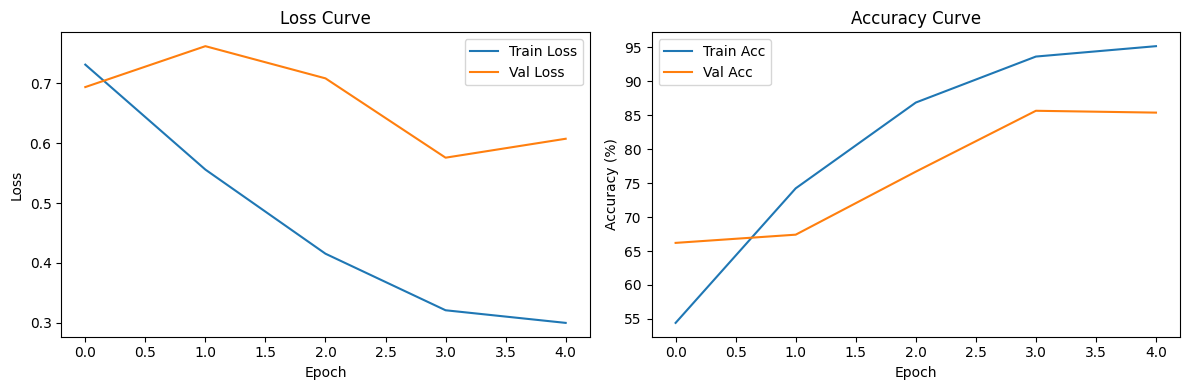

In [20]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
def get_video_probs(model, loader, k_ratio=0.2):
    model.eval()

    video_logits = defaultdict(list)
    video_labels = {}

    with torch.no_grad():
        for imgs, labels, paths in loader:
            imgs = imgs.to(device)

            outputs = model(imgs)

            # 🔥 CHANGE 1: USE LOGITS (NO SOFTMAX)
            logits = outputs[:, 1] - outputs[:, 0]  # fake vs real

            for path, logit, label in zip(paths, logits, labels):
                video_id = get_video_id_from_path(path)
                video_logits[video_id].append(logit.item())
                video_labels[video_id] = label.item()

    y_true = []
    y_score = []

    for vid in video_logits:
        logits = np.array(video_logits[vid])

        # 🔥 CHANGE 2: TEMPORAL SMOOTHING
        if len(logits) >= 3:
            logits = np.convolve(logits, np.ones(3) / 3, mode="same")

        # 🔥 CHANGE 3: TOP-K ON LOGITS
        k = max(1, int(len(logits) * k_ratio))
        topk_logits = np.sort(logits)[-k:]

        y_true.append(video_labels[vid])
        y_score.append(np.mean(topk_logits))

    return np.array(y_true), np.array(y_score)

In [22]:
def roc_curve_np(y_true, y_score):
    thresholds = np.sort(np.unique(y_score))[::-1]

    tpr = []
    fpr = []

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))

        tpr.append(TP / (P + 1e-9))
        fpr.append(FP / (N + 1e-9))

    return np.array(fpr), np.array(tpr), thresholds

In [ ]:
def auc_np(fpr, tpr): return np.trapz(tpr, fpr)

In [ ]:
y_true_vid, y_score_vid = get_video_probs(model, val_loader)

# thresholds = np.sort(np.unique(y_score_vid))[::-1]

fpr, tpr, thresholds = roc_curve_np(y_true_vid, y_score_vid)
roc_auc = auc_np(fpr, tpr)

best_threshold = find_best_threshold(fpr, tpr, thresholds)

print(f"Video-level ROC-AUC: {roc_auc:.4f}")
print(f"Best threshold (Youden J): {best_threshold:.3f}")

Video-level ROC-AUC: 0.9227
Best threshold (Youden J): 1.872


/tmp/ipykernel_55/1117193556.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  def auc_np(fpr, tpr): return np.trapz(tpr, fpr)



VIDEO-LEVEL METRICS
real  | Precision: 0.521 | Recall: 0.925 | F1: 0.667
fake  | Precision: 0.979 | Recall: 0.802 | F1: 0.881


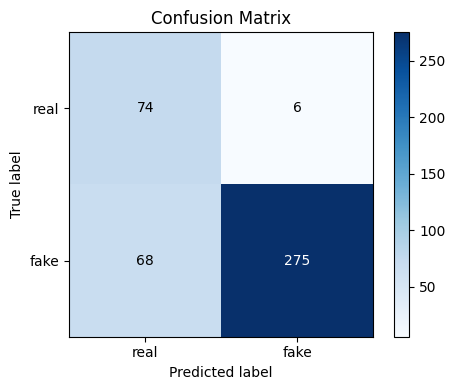

Prediction distribution: (array([0, 1]), array([142, 281]))


In [ ]:
y_true_vid, y_pred_vid = evaluate_video_level(
    model,
    val_loader,
    threshold=best_threshold
)

print("\nVIDEO-LEVEL METRICS")
classification_report_np(y_true_vid, y_pred_vid)

cm_vid = confusion_matrix_np(y_true_vid, y_pred_vid)
plot_confusion_matrix(cm_vid, ["real", "fake"])

print("Prediction distribution:",
      np.unique(y_pred_vid, return_counts=True))

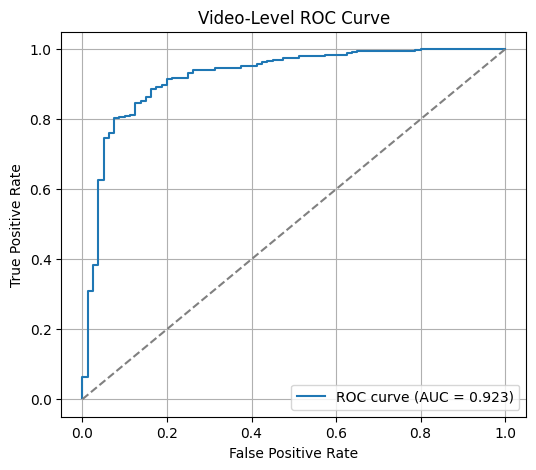

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Video-Level ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
SAVE_DIR = "/kaggle/working/model"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{SAVE_DIR}/vit_final_full_good_SE+DUAL_SCALE_6_epochs_changed.pth")
print("✅ Model saved")

✅ Model saved


In [ ]:
# Random Prediction Visualization
# import random
# import cv2
# import matplotlib.pyplot as plt

# def show_random_predictions(model, loader, n=8):
#     model.eval()

#     images = []
#     labels = []

#     # Create one big list of the whole validation set (quick way)
#     for imgs, lbls, _ in loader:
#         images.append(imgs)
#         labels.append(lbls)

#     images = torch.cat(images, dim=0)
#     labels = torch.cat(labels, dim=0)

#     # pick random indices
#     idxs = random.sample(range(len(images)), n)
#     class_names = ["real", "fake"]

#     plt.figure(figsize=(15, 4))

#     for i, idx in enumerate(idxs):
#         img = images[idx].unsqueeze(0).to(device)
#         true_label = labels[idx].item()

#         with torch.no_grad():
#             output = model(img)
#             probs = torch.softmax(output, dim=1)
#             pred = int(probs[:, 1] > 0.6)

#         # convert tensor → image for display
#         img_disp = images[idx].permute(1,2,0).numpy()
#         img_disp = (img_disp * 255).astype("uint8")

#         plt.subplot(2, n//2, i+1)
#         plt.imshow(img_disp)
#         plt.axis("off")

#         label_text = f"Pred: {class_names[pred]} | True: {class_names[true_label]}"


#         # GREEN if correct
#         if pred == true_label:
#             color = "green"
#         # RED if wrong
#         else:
#             color = "red"

#         plt.title(label_text, color=color)

#     plt.tight_layout()
#     plt.show()
    
# show_random_predictions(model, test_loader, n=8)